# 弹簧的例子

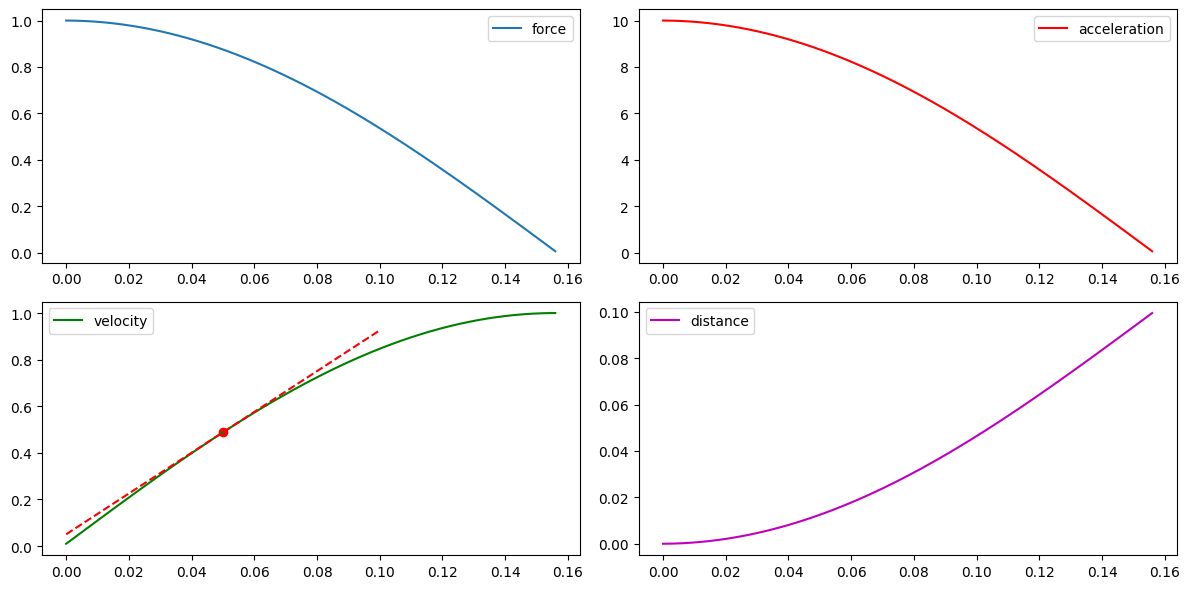

In [12]:
import numpy as np
import matplotlib.pyplot as plt

deltaT = 0.001 # sec
initX = 0.1 # m
mass = 0.1 # kg
k = 10

selectedT = 50 * deltaT
selectedV = 0
selectedA = 0

t = 0 # 时间 sec
x = initX # 距离 m
v = 0 # 速度 m/sec

fs = []
ts = []
xs = []
accs = []
vs = []

ct = 0
while True:
    ct += 1
    if ct >= 300: break

    F = x * k
    a = F / mass # 加速度
    v = v + deltaT * a
    # print(f't:{t} x:{x}, F:{F}, a:{a}, v:{v}')
    
    if np.isclose(selectedT, t):
        selectedV = v
        selectedA = a

    fs.append(F)
    ts.append(t)
    xs.append(x)
    accs.append(a)
    vs.append(v)

    x = x - v * deltaT
    if x <= 0: break
    t += deltaT


plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(ts, fs, label='force')
plt.legend()
plt.tight_layout()

plt.subplot(2, 2, 2)
plt.plot(ts, accs, 'r', label='acceleration')
plt.legend()
plt.tight_layout()

y_intercept = selectedV - selectedA * selectedT
x_line = np.linspace(selectedT-0.05, selectedT+0.05, 10)
y_line = selectedA * x_line + y_intercept

plt.subplot(2, 2, 3)
plt.plot(ts, vs, 'g', label='velocity')

plt.plot(x_line, y_line, '--r')
plt.scatter([selectedT], [selectedV], color='red')

plt.legend()
plt.tight_layout()

plt.subplot(2, 2, 4)
plt.plot(ts, 0.1-np.array(xs), 'm', label='distance')
plt.legend()
plt.tight_layout()

plt.show()

In [16]:
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["animation.html"] = "jshtml"
plt.ioff()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

frames = 16

deltaT = 0.001 # sec
initX = 0.1 # m
mass = 0.1 # kg
k = 10


def animate(frame):
    # plt.cla()
    ax1.clear()
    ax2.clear()

    selectedT = (10*frame) * deltaT
    selectedV = 0
    selectedA = 0

    t = 0 # 时间 sec
    x = initX # 距离 m
    v = 0 # 速度 m/sec

    fs = []
    ts = []
    xs = []
    accs = []
    vs = []

    ct = 0
    while True:
        ct += 1
        if ct >= 300: break

        F = x * k
        a = F / mass # 加速度
        v = v + deltaT * a
        # print(f't:{t} x:{x}, F:{F}, a:{a}, v:{v}')

        fs.append(F)
        ts.append(t)
        xs.append(x)
        accs.append(a)
        vs.append(v)

        if np.isclose(selectedT, t):
            selectedV = v
            selectedA = a

        x = x - v * deltaT
        if x <= 0: break
        t += deltaT


    ax1.plot(ts, accs, 'r', label='acceleration')
    ax1.scatter([selectedT], [selectedA], color='red', label=f't:{selectedT:.2f}, a:{selectedA:.2f}')
    ax1.fill_between(ts[:frame*10], 0, accs[:frame*10], color='skyblue', alpha=0.5)
    ax1.legend()

    y_intercept = selectedV - selectedA * selectedT
    x_line = np.linspace(selectedT-0.05, selectedT+0.05, 10)
    y_line = selectedA * x_line + y_intercept

    ax2.plot(ts, vs, 'g', label='velocity')

    ax2.plot(x_line, y_line, '--r')
    ax2.scatter([selectedT], [selectedV], color='red', label=f't:{selectedT:.2f}, v:{selectedV:.2f}, v/t:{selectedA:.2f}')
    ax2.set_xlim(0, 0.16)
    ax2.set_ylim(0, 1)
    ax2.legend()


matplotlib.animation.FuncAnimation(fig, animate, frames=frames)